# Round 3 — Autoregressive Forecasting Task
**AI Club Inductions 2026 | NIT Calicut**

Goal: Predict `wpm`, `acc`, `rawWpm`, and `consistency` for **day 999** using 999 days of Geetha's typing history.

## Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Load & Inspect Data

In [3]:
df = pd.read_csv('typing_speed_train.csv')

df = df.sort_values('days_ago', ascending=False).reset_index(drop=True)
df['day'] = range(len(df))
df['date'] = pd.to_datetime(df['date'])

print(f'Data shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'\nPrediction target: day 999 = {pd.Timestamp("2025-10-10").date()}')
df[['date','day','wpm','acc','rawWpm','consistency']].tail(5)

Data shape: (999, 7)
Date range: 2023-01-15 to 2025-10-09

Prediction target: day 999 = 2025-10-10


,date,day,wpm,acc,rawWpm,consistency
994,2025-10-05,994,127.04,100.00,127.04,83.92
995,2025-10-06,995,105.64,100.00,105.64,82.16
996,2025-10-07,996,103.97,100.00,103.97,55.57
997,2025-10-08,997,95.76,92.31,121.45,59.69
998,2025-10-09,998,93.46,92.31,103.85,66.42


In [4]:
df[['wpm','acc','rawWpm','consistency']].describe()

,wpm,acc,rawWpm,consistency
count,999.000000,999.000000,999.000000,999.000000
mean,85.748058,96.192032,89.908298,67.370070
std,17.857199,4.044028,19.673983,12.349825
min,23.440000,76.190000,26.790000,0.760000
25%,72.525000,94.000000,74.415000,59.020000
50%,83.540000,96.720000,87.050000,66.570000
75%,98.870000,100.000000,105.610000,75.940000
max,150.680000,100.000000,150.680000,95.860000


## Exploratory Data Analysis

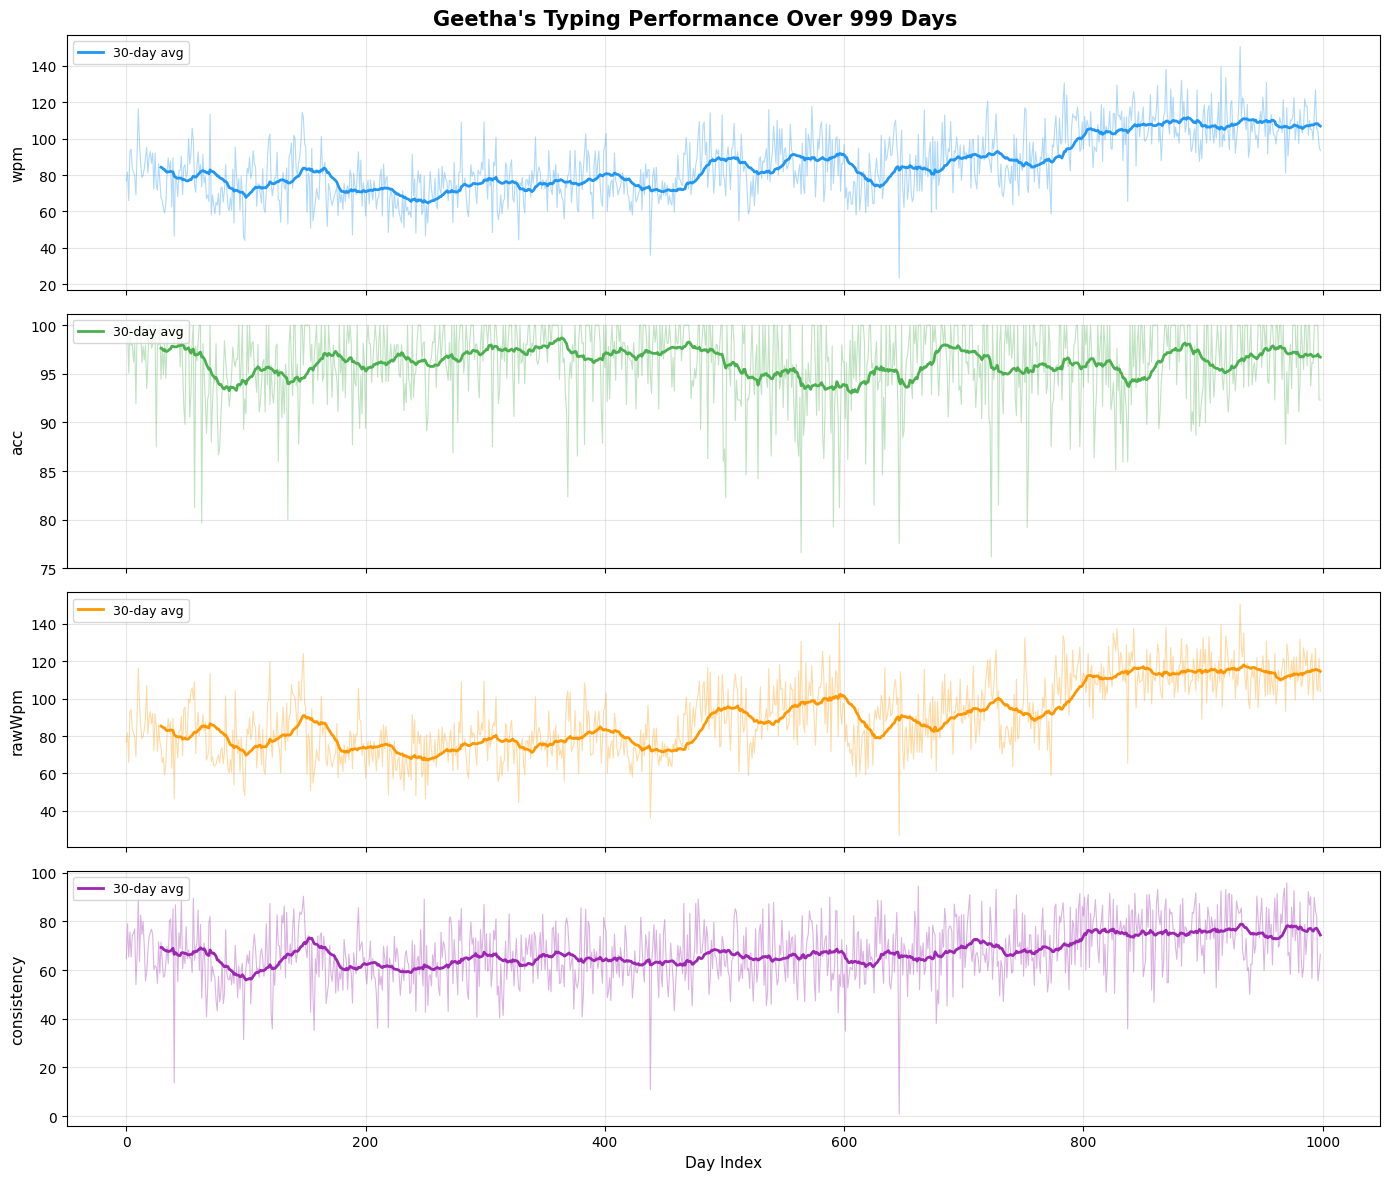

Clear upward trend in WPM and rawWpm over time.


In [5]:
targets = ['wpm', 'acc', 'rawWpm', 'consistency']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Geetha's Typing Performance Over 999 Days", fontsize=15, fontweight='bold')

for ax, t, c in zip(axes, targets, colors):
    ax.plot(df['day'], df[t], alpha=0.35, color=c, linewidth=0.8)
    ax.plot(df['day'], df[t].rolling(30).mean(), color=c, linewidth=2, label='30-day avg')
    ax.set_ylabel(t, fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Day Index', fontsize=11)
plt.tight_layout()
plt.savefig('eda_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Clear upward trend in WPM and rawWpm over time.')

In [6]:
print('Missing values:')
print(df[targets].isnull().sum())

print('\nRecent 30-day averages:')
print(df[targets].tail(30).mean().round(2))

Missing values:
wpm            0
acc            0
rawWpm         0
consistency    0
dtype: int64

Recent 30-day averages:
wpm            106.99
acc             96.73
rawWpm         114.62
consistency     74.38
dtype: float64


## Feature Engineering — Lag Features

Since LightGBM doesn't natively understand time order, we create lag features and rolling statistics as inputs. This gives the model the temporal context it needs to make a next-step prediction.


Lag features are simply past values of each metric at specific time offsets. For example, wpm_lag1 is yesterday's WPM, wpm_lag7 is WPM from 7 days ago, and so on. We create lags at intervals of 1, 2, 3, 5, 7, 14, 21, and 30 days for all 4 metrics. This lets the model see both the very recent trend (last 1–3 days) and longer-term patterns (last 2–4 weeks) simultaneously.


Rolling statistics summarise behaviour over a window of time rather than capturing a single point. We compute the mean and standard deviation of each metric over the last 7, 14, and 30 days.

In [7]:
LAGS    = [1, 2, 3, 5, 7, 14, 21, 30]
WINDOWS = [7, 14, 30]

def make_features(df, targets=targets, lags=LAGS, windows=WINDOWS):
    feat = pd.DataFrame(index=df.index)
    feat['day'] = df['day']
    for t in targets:
        for lag in lags:
            feat[f'{t}_lag{lag}'] = df[t].shift(lag)
        for w in windows:
            feat[f'{t}_roll_mean_{w}'] = df[t].shift(1).rolling(w).mean()
            feat[f'{t}_roll_std_{w}']  = df[t].shift(1).rolling(w).std()
    return feat

feat = make_features(df)
feat_cols = list(feat.columns)

print(f'Total features: {len(feat_cols)}')
print('Sample features:', feat_cols[0:],)

Total features: 57
Sample features: ['day', 'wpm_lag1', 'wpm_lag2', 'wpm_lag3', 'wpm_lag5', 'wpm_lag7', 'wpm_lag14', 'wpm_lag21', 'wpm_lag30', 'wpm_roll_mean_7', 'wpm_roll_std_7', 'wpm_roll_mean_14', 'wpm_roll_std_14', 'wpm_roll_mean_30', 'wpm_roll_std_30', 'acc_lag1', 'acc_lag2', 'acc_lag3', 'acc_lag5', 'acc_lag7', 'acc_lag14', 'acc_lag21', 'acc_lag30', 'acc_roll_mean_7', 'acc_roll_std_7', 'acc_roll_mean_14', 'acc_roll_std_14', 'acc_roll_mean_30', 'acc_roll_std_30', 'rawWpm_lag1', 'rawWpm_lag2', 'rawWpm_lag3', 'rawWpm_lag5', 'rawWpm_lag7', 'rawWpm_lag14', 'rawWpm_lag21', 'rawWpm_lag30', 'rawWpm_roll_mean_7', 'rawWpm_roll_std_7', 'rawWpm_roll_mean_14', 'rawWpm_roll_std_14', 'rawWpm_roll_mean_30', 'rawWpm_roll_std_30', 'consistency_lag1', 'consistency_lag2', 'consistency_lag3', 'consistency_lag5', 'consistency_lag7', 'consistency_lag14', 'consistency_lag21', 'consistency_lag30', 'consistency_roll_mean_7', 'consistency_roll_std_7', 'consistency_roll_mean_14', 'consistency_roll_std_14', '

## Train / Validation Split

In [8]:
# Drop rows with NaN features (early rows don't have enough lag history)
valid_idx = feat.dropna().index
X_all = feat.loc[valid_idx, feat_cols].values
y_all = df.loc[valid_idx, targets].values

VAL_SIZE = 150
split = len(valid_idx) - VAL_SIZE

X_train, X_val = X_all[:split], X_all[split:]
y_train, y_val = y_all[:split], y_all[split:]

print(f'Training samples:   {len(X_train)}')
print(f'Validation samples: {len(X_val)}')

Training samples:   819
Validation samples: 150


## Model Training — LightGBM

We train one LightGBM regressor per metric. LightGBM is a gradient-boosted decision tree framework. It is 
fast, handles tabular data well, and regularises naturally. We use early stopping on the validation set to avoid overfitting.

In [9]:
params_per_target = {
    'wpm':         dict(n_estimators=453, learning_rate=0.0361, max_depth=3, num_leaves=41, subsample=0.682, colsample_bytree=0.507, min_child_samples=17),
    'acc':         dict(n_estimators=524, learning_rate=0.0673, max_depth=6, num_leaves=39, subsample=0.737, colsample_bytree=0.886, min_child_samples=18),
    'rawWpm':      dict(n_estimators=464, learning_rate=0.0763, max_depth=8, num_leaves=28, subsample=0.555, colsample_bytree=0.915, min_child_samples=13),
    'consistency': dict(n_estimators=467, learning_rate=0.0711, max_depth=7, num_leaves=48, subsample=0.500, colsample_bytree=0.543, min_child_samples=29),
}

models = {}
val_preds_all = {}

for i, t in enumerate(targets):
    m = lgb.LGBMRegressor(**params_per_target[t], random_state=42, verbose=-1)
    m.fit(
        X_train, y_train[:, i],
        eval_set=[(X_val, y_val[:, i])],
        callbacks=[lgb.early_stopping(40, verbose=False)]
    )
    models[t] = m
    preds = m.predict(X_val)
    val_preds_all[t] = preds
    mae  = np.mean(np.abs(preds - y_val[:, i]))
    rmse = np.sqrt(np.mean((preds - y_val[:, i])**2))
    print(f'{t:12s} → MAE: {mae:.3f}  | RMSE: {rmse:.3f}  | Best iter: {m.best_iteration_}')

wpm          → MAE: 9.639  | RMSE: 13.090  | Best iter: 120
acc          → MAE: 3.058  | RMSE: 3.506  | Best iter: 1
rawWpm       → MAE: 9.356  | RMSE: 11.757  | Best iter: 57
consistency  → MAE: 9.851  | RMSE: 11.820  | Best iter: 33


## Validation — Visual Check

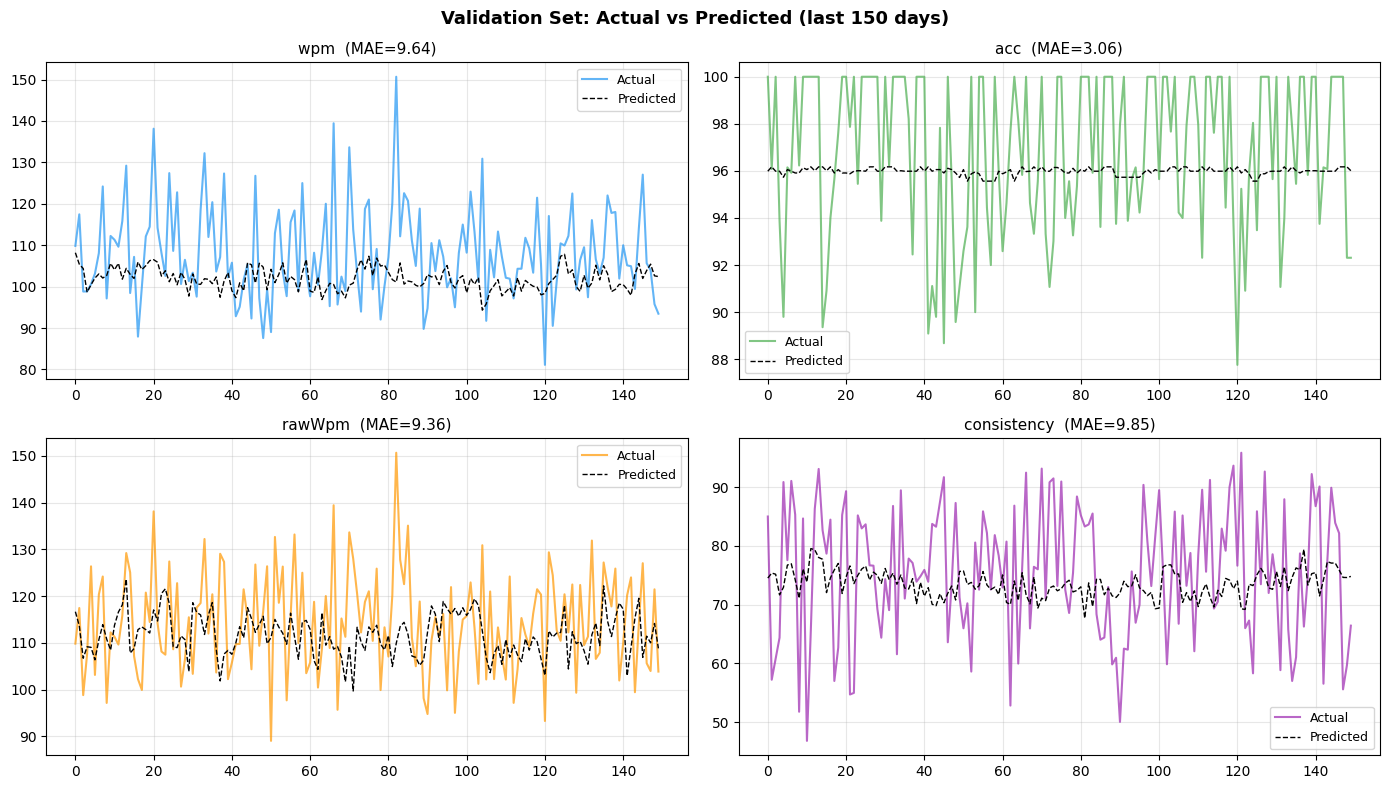

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle('Validation Set: Actual vs Predicted (last 150 days)', fontsize=13, fontweight='bold')

for ax, t, c in zip(axes, targets, colors):
    actual = y_val[:, targets.index(t)]
    pred   = val_preds_all[t]
    x = range(len(actual))
    ax.plot(x, actual, label='Actual', color=c, alpha=0.7)
    ax.plot(x, pred,   label='Predicted', color='black', linestyle='--', linewidth=1)
    mae = np.mean(np.abs(pred - actual))
    ax.set_title(f'{t}  (MAE={mae:.2f})', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## Predict Day 999

In [12]:
row = {'day': 999}

for t in targets:
    vals = df[t].values  
    for lag in LAGS:
        row[f'{t}_lag{lag}'] = vals[-lag] if lag <= len(vals) else np.nan
    for w in WINDOWS:
        window_vals = vals[-w:] if w <= len(vals) else vals
        row[f'{t}_roll_mean_{w}'] = np.mean(window_vals)
        row[f'{t}_roll_std_{w}']  = np.std(window_vals)

X_pred = pd.DataFrame([row])[feat_cols].values

final_preds = {}
for t in targets:
    final_preds[t] = round(models[t].predict(X_pred)[0], 2)

print('=== Final Predictions for Day 999 (2025-10-10) ===')
for t, v in final_preds.items():
    print(f'  {t:12s}: {v}')

=== Final Predictions for Day 999 (2025-10-10) ===
  wpm         : 104.22
  acc         : 95.99
  rawWpm      : 111.51
  consistency : 74.03


In [13]:
print('Recent actuals (last 7 days):')
print(df[['date'] + targets].tail(7).to_string(index=False))
print()
print('30-day rolling average (most recent):')
print(df[targets].tail(30).mean().round(2).to_dict())

Recent actuals (last 7 days):
      date    wpm    acc  rawWpm  consistency
2025-10-03  99.43  96.08   99.43        77.59
2025-10-04 114.05 100.00  114.05        89.90
2025-10-05 127.04 100.00  127.04        83.92
2025-10-06 105.64 100.00  105.64        82.16
2025-10-07 103.97 100.00  103.97        55.57
2025-10-08  95.76  92.31  121.45        59.69
2025-10-09  93.46  92.31  103.85        66.42

30-day rolling average (most recent):
{'wpm': 106.99, 'acc': 96.73, 'rawWpm': 114.62, 'consistency': 74.38}


## Save Predictions

In [14]:
out = pd.DataFrame([final_preds])[['wpm', 'acc', 'rawWpm', 'consistency']]
out.to_csv('predictions.csv', index=False)
print('Saved predictions.csv')
print(out)

Saved predictions.csv
      wpm    acc  rawWpm  consistency
0  104.22  95.99  111.51        74.03


## Feature Importance

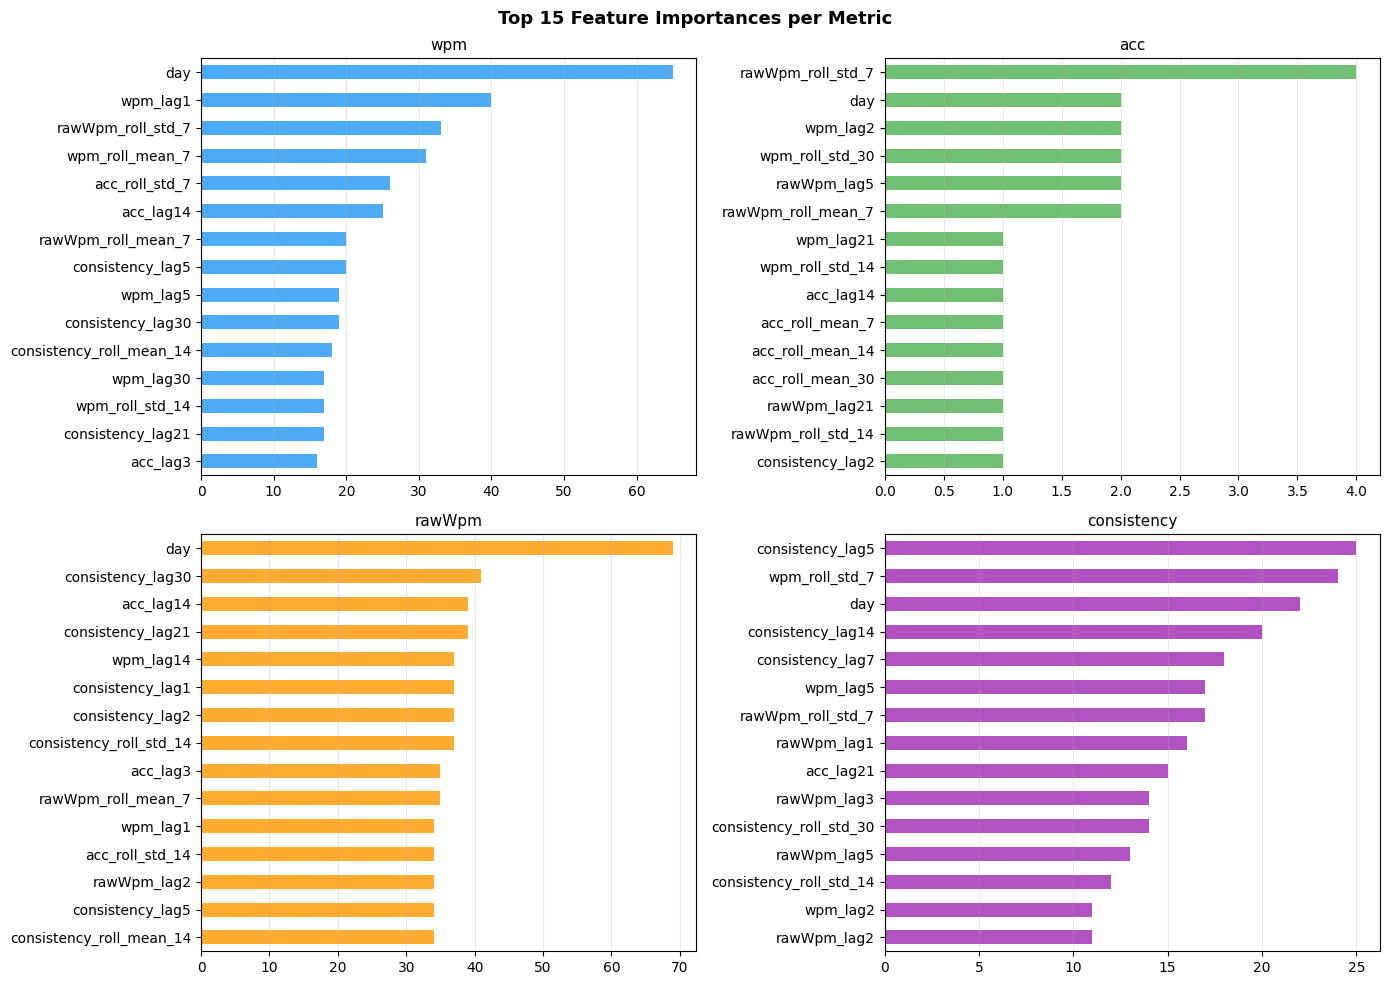

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle('Top 15 Feature Importances per Metric', fontsize=13, fontweight='bold')

for ax, t, c in zip(axes, targets, colors):
    imp = pd.Series(models[t].feature_importances_, index=feat_cols)
    top = imp.nlargest(15)
    top.plot(kind='barh', ax=ax, color=c, alpha=0.8)
    ax.set_title(t, fontsize=11)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()